In [2]:
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA RTX A6000


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
print("GPU 1 selected")

GPU 1 selected


Cutivar Dictionary:

In [3]:
DATASET_DIR = Path("Dataset")

CULTIVARS = {
    "AAC_Chrome":     {"label": "AAC Chrome",    "cys": 0.317211},
    "AAC_Lacombe":    {"label": "AAC Lacombe",   "cys": 0.338561},
    "AAC_Liscard":    {"label": "AAC Liscard",   "cys": 0.325405},
    "CDC_Amarillo":   {"label": "CDC Amarillo",  "cys": 0.358930},
    "CDC_Athabasca":  {"label": "CDC Athabasca", "cys": 0.341203},
    "CDC_Canary":     {"label": "CDC Canary",    "cys": 0.314476},
    "CDC_Dakota":     {"label": "CDC Dakota",    "cys": 0.332835},
    "CDC_Golden":     {"label": "CDC Golden",    "cys": 0.359066},
    "CDC_Greenwater": {"label": "CDC Greenwater","cys": 0.346381},
    "CDC_Inca":       {"label": "CDC Inca",      "cys": 0.365342},
    "CDC_Jasper":     {"label": "CDC Jasper",    "cys": 0.337341},
    "CDC_Lewochko":   {"label": "CDC Lewochko",  "cys": 0.341267},
    "CDC_Meadow":     {"label": "CDC Meadow",    "cys": 0.312012},
    "CDC_Patrick":    {"label": "CDC Patrick",   "cys": 0.338404},
    "CDC_Saffron":    {"label": "CDC Saffron",   "cys": 0.346789},
    "CDC_Spectrum":   {"label": "CDC Spectrum",  "cys": 0.373175},
    "CDC_Spruce":     {"label": "CDC Spruce",    "cys": 0.345676},
    "CDC_Striker":    {"label": "CDC Striker",   "cys": 0.344968},
    "CDC_Tetris":     {"label": "CDC Tetris",    "cys": 0.342040},
    "Redbat88":       {"label": "Redbat 88",     "cys": 0.316257},
}

read_spectrum function:

In [5]:
def read_spectrum(filepath):
    raman_shifts = []
    intensities = []

    with open(filepath, 'r', encoding='latin-1') as f:
        lines = f.readlines()

    data_started = False
    for line in lines:
        line = line.strip()
        if line.startswith("Pixel;"):
            data_started = True
            continue
        if not data_started:
            continue
        parts = line.split(';')
        if len(parts) < 8:
            continue
        wl_str = parts[1].strip()
        if not wl_str or wl_str == '   ':
            continue
        try:
            raman_shift = float(parts[3])
            dark_sub    = float(parts[7])
            raman_shifts.append(raman_shift)
            intensities.append(dark_sub)
        except ValueError:
            continue

    return raman_shifts, intensities

Load all spectra:

In [6]:
all_data = {}

for folder_name, meta in CULTIVARS.items():
    folder_path = DATASET_DIR / folder_name
    if not folder_path.exists():
        print(f"Not found: {folder_name}")
        continue
    files = list(folder_path.rglob("*.txt"))
    spectra = []
    for f in files:
        rs, intens = read_spectrum(f)
        if len(rs) > 100:
            spectra.append((rs, intens))
    all_data[folder_name] = spectra
    print(f"{meta['label']}: {len(spectra)} spectra loaded")

AAC Chrome: 324 spectra loaded
AAC Lacombe: 324 spectra loaded
AAC Liscard: 324 spectra loaded
CDC Amarillo: 324 spectra loaded
CDC Athabasca: 324 spectra loaded
CDC Canary: 324 spectra loaded
CDC Dakota: 324 spectra loaded
CDC Golden: 324 spectra loaded
CDC Greenwater: 324 spectra loaded
CDC Inca: 324 spectra loaded
CDC Jasper: 324 spectra loaded
CDC Lewochko: 324 spectra loaded
CDC Meadow: 324 spectra loaded
CDC Patrick: 324 spectra loaded
CDC Saffron: 324 spectra loaded
CDC Spectrum: 324 spectra loaded
CDC Spruce: 324 spectra loaded
CDC Striker: 324 spectra loaded
CDC Tetris: 324 spectra loaded
Redbat 88: 324 spectra loaded


Preprocessing functions and combos:

In [7]:
def savitzky_golay_smooth(X, window=11, poly=3):
    return savgol_filter(X, window_length=window, polyorder=poly, axis=1)

def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

def msc(X):
    mean_spectrum = X.mean(axis=0)
    X_msc = np.zeros_like(X)
    for i in range(X.shape[0]):
        coef = np.polyfit(mean_spectrum, X[i], 1)
        X_msc[i] = (X[i] - coef[1]) / coef[0]
    return X_msc

def first_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=1, axis=1)

def second_derivative(X, window=11, poly=3):
    return savgol_filter(X, window_length=window,
                         polyorder=poly, deriv=2, axis=1)

preprocessing_combos = {
    "SG + SNV":           lambda X: snv(savitzky_golay_smooth(X)),
    "SG + MSC":           lambda X: msc(savitzky_golay_smooth(X)),
    "SG + 1st Deriv":     lambda X: first_derivative(savitzky_golay_smooth(X)),
    "SG + 2nd Deriv":     lambda X: second_derivative(savitzky_golay_smooth(X)),
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

print(f"Preprocessing combinations: {len(preprocessing_combos)}")

Preprocessing combinations: 8


 Build X and y:

In [8]:
X = []
y = []

for folder_name, meta in CULTIVARS.items():
    spectra = all_data.get(folder_name, [])
    for rs, intens in spectra:
        X.append(intens)
        y.append(meta['cys'])

X = np.array(X)
y = np.array(y)

cultivar_names = list(CULTIVARS.keys())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6480, 1530)
y shape: (6480,)


LSTM Architecture:

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1530, hidden_size=128, 
                 num_layers=2, dropout=0.3):
        super(LSTMModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        
        # ── LSTM layers ──
        self.lstm = nn.LSTM(
            input_size=1,          # each time step = 1 feature (one wavenumber)
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,      # input shape: (batch, seq_len, features)
            dropout=dropout,
            bidirectional=True     # reads spectrum left to right AND right to left
        )
        
        # ── Fully connected layers ──
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),  # *2 because bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        # x shape: (batch, 1530)
        x = x.unsqueeze(2)              # → (batch, 1530, 1) for LSTM
        
        lstm_out, _ = self.lstm(x)      # → (batch, 1530, hidden*2)
        
        # Take only last time step output
        out = lstm_out[:, -1, :]        # → (batch, hidden*2)
        
        out = self.fc_layers(out)       # → (batch, 1)
        return out.squeeze(1)           # → (batch,)

# Test architecture
model_test = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
print(model_test)
print(f"\nTotal parameters: {sum(p.numel() for p in model_test.parameters()):,}")

# Test with dummy input
dummy = torch.randn(4, 1530)
out   = model_test(dummy)
print(f"Input shape:  {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4,)")

LSTMModel(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 545,921
Input shape:  torch.Size([4, 1530])
Output shape: torch.Size([4])  ← should be (4,)


Training Function:

In [10]:
def train_model(model, X_train, y_train, X_val, y_val,
                epochs=100, batch_size=32, lr=1e-4):

    X_tr = torch.FloatTensor(X_train).to(device)
    y_tr = torch.FloatTensor(y_train).to(device)
    X_v  = torch.FloatTensor(X_val).to(device)
    y_v  = torch.FloatTensor(y_val).to(device)

    dataset   = TensorDataset(X_tr, y_tr)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.SmoothL1Loss(beta=0.02)
    optimizer = optim.AdamW(model.parameters(),
                            lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(loader),
                    epochs=epochs)

    model.to(device)

    best_val_loss = np.inf
    best_weights  = None
    train_losses  = []
    val_losses    = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(loader)
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_v)
            val_loss   = criterion(y_val_pred, y_v).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} — "
                  f"Train Loss: {avg_train_loss:.5f}  "
                  f"Val Loss: {val_loss:.5f}")

    model.load_state_dict(best_weights)
    print(f"\nBest validation loss: {best_val_loss:.5f}")
    return model, train_losses, val_losses

LSTM Preprocessing Comparisonpython:

In [ ]:
results_lstm = []

for combo_name, preprocess_fn in preprocessing_combos.items():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    try:
        X_combo = preprocess_fn(X)
    except Exception as e:
        print(f"  Failed: {e}")
        continue

    # 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    # Train LSTM 80/20
    torch.manual_seed(42)
    model_combo = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_combo, _, _ = train_model(
        model=model_combo,
        X_train=X_tr, y_train=y_tr,
        X_val=X_te,   y_val=y_te,
        epochs=100, batch_size=32, lr=1e-4
    )

    model_combo.eval()
    with torch.no_grad():
        y_pred_te = model_combo(
            torch.FloatTensor(X_te).to(device)
        ).cpu().numpy()

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020

    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    # LOCOCV
    all_true, all_pred = [], []

    for fold_idx, held_out in enumerate(cultivar_names):
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        torch.manual_seed(42)
        model_loco = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
        model_loco, _, _ = train_model(
            model=model_loco,
            X_train=np.array(X_tr_l),
            y_train=np.array(y_tr_l),
            X_val=np.array(X_te_l),
            y_val=np.array(y_te_l),
            epochs=100, batch_size=32, lr=1e-4
        )

        model_loco.eval()
        with torch.no_grad():
            y_pred_l = model_loco(
                torch.FloatTensor(np.array(X_te_l)).to(device)
            ).cpu().numpy()

        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
        print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"\n  LOCO → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_lstm.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })


Testing: SG + SNV
Epoch  10/100 — Train Loss: 0.03644  Val Loss: 0.00781
Epoch  20/100 — Train Loss: 0.03245  Val Loss: 0.00726
Epoch  30/100 — Train Loss: 0.02688  Val Loss: 0.00617
Epoch  40/100 — Train Loss: 0.02107  Val Loss: 0.00630
Epoch  50/100 — Train Loss: 0.01614  Val Loss: 0.00637
Epoch  60/100 — Train Loss: 0.01301  Val Loss: 0.00617
Epoch  70/100 — Train Loss: 0.01080  Val Loss: 0.00611
Epoch  80/100 — Train Loss: 0.00955  Val Loss: 0.00615
Epoch  90/100 — Train Loss: 0.00927  Val Loss: 0.00614
Epoch 100/100 — Train Loss: 0.00921  Val Loss: 0.00613

Best validation loss: 0.00610
  80/20 → RMSE: 0.0162  R²: 0.0202  RPD: 1.0103
Epoch  10/100 — Train Loss: 0.03623  Val Loss: 0.01056
Epoch  20/100 — Train Loss: 0.03168  Val Loss: 0.00041
Epoch  30/100 — Train Loss: 0.02483  Val Loss: 0.00290
Epoch  40/100 — Train Loss: 0.01845  Val Loss: 0.00668
Epoch  50/100 — Train Loss: 0.01257  Val Loss: 0.01655
Epoch  60/100 — Train Loss: 0.00933  Val Loss: 0.01224
Epoch  70/100 — Train 

In [11]:
# Only run missing combinations
missing_combos = {
    "SG + SNV + 1st Der": lambda X: first_derivative(snv(savitzky_golay_smooth(X))),
    "SG + SNV + 2nd Der": lambda X: second_derivative(snv(savitzky_golay_smooth(X))),
    "SG + MSC + 1st Der": lambda X: first_derivative(msc(savitzky_golay_smooth(X))),
    "SG + MSC + 2nd Der": lambda X: second_derivative(msc(savitzky_golay_smooth(X))),
}

results_lstm_missing = []

for combo_name, preprocess_fn in missing_combos.items():
    print(f"\n{'='*50}")
    print(f"Testing: {combo_name}")
    print(f"{'='*50}")

    X_combo = preprocess_fn(X)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    torch.manual_seed(42)
    model_combo = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_combo, _, _ = train_model(
        model=model_combo,
        X_train=X_tr, y_train=y_tr,
        X_val=X_te,   y_val=y_te,
        epochs=100, batch_size=32, lr=1e-4
    )

    model_combo.eval()
    with torch.no_grad():
        y_pred_te = model_combo(
            torch.FloatTensor(X_te).to(device)
        ).cpu().numpy()

    rmse_8020 = np.sqrt(mean_squared_error(y_te, y_pred_te))
    r2_8020   = r2_score(y_te, y_pred_te)
    rpd_8020  = y_te.std() / rmse_8020
    print(f"  80/20 → RMSE: {rmse_8020:.4f}  R²: {r2_8020:.4f}  RPD: {rpd_8020:.4f}")

    all_true, all_pred = [], []
    for fold_idx, held_out in enumerate(cultivar_names):
        X_tr_l, y_tr_l = [], []
        X_te_l, y_te_l = [], []

        for folder_name, meta in CULTIVARS.items():
            spectra = all_data.get(folder_name, [])
            for rs, intens in spectra:
                arr     = np.array([intens])
                arr_pre = preprocess_fn(arr)[0]
                if folder_name == held_out:
                    X_te_l.append(arr_pre)
                    y_te_l.append(meta['cys'])
                else:
                    X_tr_l.append(arr_pre)
                    y_tr_l.append(meta['cys'])

        torch.manual_seed(42)
        model_loco = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
        model_loco, _, _ = train_model(
            model=model_loco,
            X_train=np.array(X_tr_l),
            y_train=np.array(y_tr_l),
            X_val=np.array(X_te_l),
            y_val=np.array(y_te_l),
            epochs=100, batch_size=32, lr=1e-4
        )

        model_loco.eval()
        with torch.no_grad():
            y_pred_l = model_loco(
                torch.FloatTensor(np.array(X_te_l)).to(device)
            ).cpu().numpy()

        fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
        print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")
        all_true.extend(y_te_l)
        all_pred.extend(y_pred_l)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    rmse_loco = np.sqrt(mean_squared_error(all_true, all_pred))
    r2_loco   = r2_score(all_true, all_pred)
    rpd_loco  = all_true.std() / rmse_loco

    print(f"\n  LOCO → RMSE: {rmse_loco:.4f}  R²: {r2_loco:.4f}  RPD: {rpd_loco:.4f}")

    results_lstm_missing.append({
        "Preprocessing": combo_name,
        "RMSE_8020":     rmse_8020,
        "R2_8020":       r2_8020,
        "RPD_8020":      rpd_8020,
        "RMSE_LOCO":     rmse_loco,
        "R2_LOCO":       r2_loco,
        "RPD_LOCO":      rpd_loco,
    })

print("\n MISSING LSTM COMBINATIONS DONE!")

# Raw baseline
print(f"\n{'='*50}")
print("Testing: Raw (no preprocessing)")
print(f"{'='*50}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

torch.manual_seed(42)
model_raw = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
model_raw, _, _ = train_model(
    model=model_raw,
    X_train=X_tr, y_train=y_tr,
    X_val=X_te,   y_val=y_te,
    epochs=100, batch_size=32, lr=1e-4
)

model_raw.eval()
with torch.no_grad():
    y_pred_raw = model_raw(
        torch.FloatTensor(X_te).to(device)
    ).cpu().numpy()

rmse_8020_raw = np.sqrt(mean_squared_error(y_te, y_pred_raw))
r2_8020_raw   = r2_score(y_te, y_pred_raw)
rpd_8020_raw  = y_te.std() / rmse_8020_raw
print(f"  80/20 → RMSE: {rmse_8020_raw:.4f}  R²: {r2_8020_raw:.4f}  RPD: {rpd_8020_raw:.4f}")

all_true_raw, all_pred_raw = [], []
for fold_idx, held_out in enumerate(cultivar_names):
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []
    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            if folder_name == held_out:
                X_te_l.append(intens)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(intens)
                y_tr_l.append(meta['cys'])

    torch.manual_seed(42)
    model_raw_loco = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_raw_loco, _, _ = train_model(
        model=model_raw_loco,
        X_train=np.array(X_tr_l),
        y_train=np.array(y_tr_l),
        X_val=np.array(X_te_l),
        y_val=np.array(y_te_l),
        epochs=100, batch_size=32, lr=1e-4
    )

    model_raw_loco.eval()
    with torch.no_grad():
        y_pred_l = model_raw_loco(
            torch.FloatTensor(np.array(X_te_l)).to(device)
        ).cpu().numpy()

    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"    Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")
    all_true_raw.extend(y_te_l)
    all_pred_raw.extend(y_pred_l)

all_true_raw = np.array(all_true_raw)
all_pred_raw = np.array(all_pred_raw)

rmse_loco_raw = np.sqrt(mean_squared_error(all_true_raw, all_pred_raw))
r2_loco_raw   = r2_score(all_true_raw, all_pred_raw)
rpd_loco_raw  = all_true_raw.std() / rmse_loco_raw
print(f"\n  LOCO → RMSE: {rmse_loco_raw:.4f}  R²: {r2_loco_raw:.4f}  RPD: {rpd_loco_raw:.4f}")

results_lstm_missing.append({
    "Preprocessing": "Raw",
    "RMSE_8020":     rmse_8020_raw,
    "R2_8020":       r2_8020_raw,
    "RPD_8020":      rpd_8020_raw,
    "RMSE_LOCO":     rmse_loco_raw,
    "R2_LOCO":       r2_loco_raw,
    "RPD_LOCO":      rpd_loco_raw,
})

print("\n ALL LSTM RESULTS COMPLETE!")


Testing: SG + SNV + 1st Der
Epoch  10/100 — Train Loss: 0.03518  Val Loss: 0.00680
Epoch  20/100 — Train Loss: 0.03254  Val Loss: 0.00729
Epoch  30/100 — Train Loss: 0.02696  Val Loss: 0.00634
Epoch  40/100 — Train Loss: 0.02114  Val Loss: 0.00654
Epoch  50/100 — Train Loss: 0.01625  Val Loss: 0.00656
Epoch  60/100 — Train Loss: 0.01310  Val Loss: 0.00639
Epoch  70/100 — Train Loss: 0.01097  Val Loss: 0.00633
Epoch  80/100 — Train Loss: 0.00974  Val Loss: 0.00638
Epoch  90/100 — Train Loss: 0.00947  Val Loss: 0.00637
Epoch 100/100 — Train Loss: 0.00940  Val Loss: 0.00636

Best validation loss: 0.00632
  80/20 → RMSE: 0.0164  R²: 0.0004  RPD: 1.0002
Epoch  10/100 — Train Loss: 0.03549  Val Loss: 0.01062
Epoch  20/100 — Train Loss: 0.03106  Val Loss: 0.00036
Epoch  30/100 — Train Loss: 0.02456  Val Loss: 0.00254
Epoch  40/100 — Train Loss: 0.01857  Val Loss: 0.00682
Epoch  50/100 — Train Loss: 0.01283  Val Loss: 0.01618
Epoch  60/100 — Train Loss: 0.00973  Val Loss: 0.01134
Epoch  70/10

LSTM Results Table and Comparison Plot:

              LSTM PREPROCESSING COMPARISON RESULTS
Preprocessing           RMSE_8020  R2_8020  RPD_8020  RMSE_LOCO   R2_LOCO  RPD_LOCO
------------------------------------------------------------------------------------------
SG + SNV                   0.0162   0.0202    1.0103     0.0114    0.5236    1.4488
SG + MSC                   0.0143   0.2348    1.1432     0.0091    0.6918    1.8014
SG + 1st Deriv             0.0163   0.0113    1.0057     0.0109    0.5605    1.5085
SG + 2nd Deriv             0.0163   0.0061    1.0030     0.0115    0.5143    1.4349
SG + SNV + 1st Der         0.0164   0.0004    1.0002     0.0112    0.5364    1.4687
SG + SNV + 2nd Der         0.0164   0.0007    1.0003     0.0112    0.5366    1.4690
SG + MSC + 1st Der         0.0161   0.0372    1.0191     0.0109    0.5605    1.5085
SG + MSC + 2nd Der         0.0162   0.0225    1.0114     0.0115    0.5143    1.4349
Raw                        0.0161   0.0335    1.0172     0.0093    0.6772    1.7602

Best 80/20 prepr

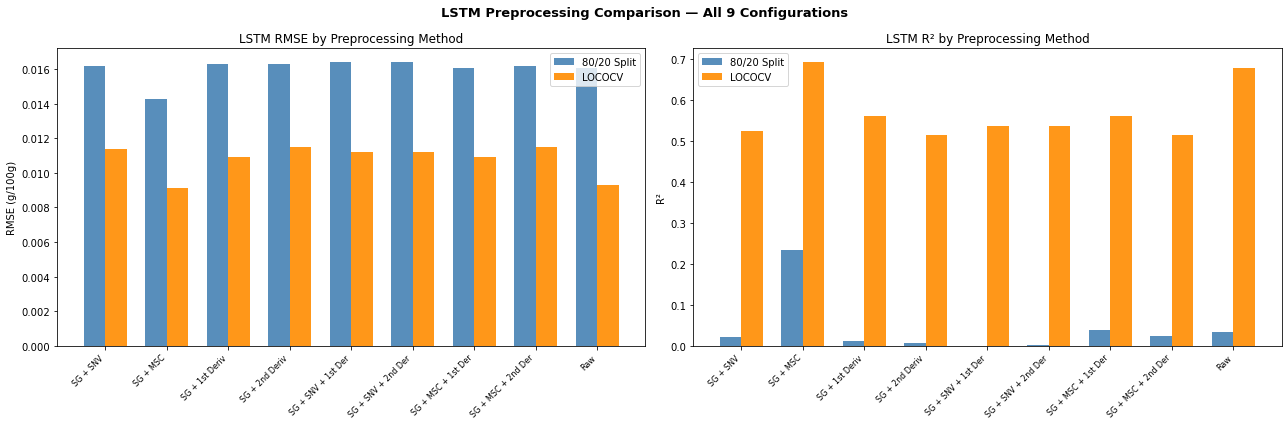

In [13]:
import pandas as pd

results_lstm_all = [
    {"Preprocessing": "SG + SNV",           "RMSE_8020": 0.0162, "R2_8020": 0.0202, "RPD_8020": 1.0103, "RMSE_LOCO": 0.0114, "R2_LOCO": 0.5236, "RPD_LOCO": 1.4488},
    {"Preprocessing": "SG + MSC",           "RMSE_8020": 0.0143, "R2_8020": 0.2348, "RPD_8020": 1.1432, "RMSE_LOCO": 0.0091, "R2_LOCO": 0.6918, "RPD_LOCO": 1.8014},
    {"Preprocessing": "SG + 1st Deriv",     "RMSE_8020": 0.0163, "R2_8020": 0.0113, "RPD_8020": 1.0057, "RMSE_LOCO": 0.0109, "R2_LOCO": 0.5605, "RPD_LOCO": 1.5085},
    {"Preprocessing": "SG + 2nd Deriv",     "RMSE_8020": 0.0163, "R2_8020": 0.0061, "RPD_8020": 1.0030, "RMSE_LOCO": 0.0115, "R2_LOCO": 0.5143, "RPD_LOCO": 1.4349},
    {"Preprocessing": "SG + SNV + 1st Der", "RMSE_8020": 0.0164, "R2_8020": 0.0004, "RPD_8020": 1.0002, "RMSE_LOCO": 0.0112, "R2_LOCO": 0.5364, "RPD_LOCO": 1.4687},
    {"Preprocessing": "SG + SNV + 2nd Der", "RMSE_8020": 0.0164, "R2_8020": 0.0007, "RPD_8020": 1.0003, "RMSE_LOCO": 0.0112, "R2_LOCO": 0.5366, "RPD_LOCO": 1.4690},
    {"Preprocessing": "SG + MSC + 1st Der", "RMSE_8020": 0.0161, "R2_8020": 0.0372, "RPD_8020": 1.0191, "RMSE_LOCO": 0.0109, "R2_LOCO": 0.5605, "RPD_LOCO": 1.5085},
    {"Preprocessing": "SG + MSC + 2nd Der", "RMSE_8020": 0.0162, "R2_8020": 0.0225, "RPD_8020": 1.0114, "RMSE_LOCO": 0.0115, "R2_LOCO": 0.5143, "RPD_LOCO": 1.4349},
    {"Preprocessing": "Raw",                "RMSE_8020": 0.0161, "R2_8020": 0.0335, "RPD_8020": 1.0172, "RMSE_LOCO": 0.0093, "R2_LOCO": 0.6772, "RPD_LOCO": 1.7602},
]

df_lstm = pd.DataFrame(results_lstm_all)

print("="*90)
print("              LSTM PREPROCESSING COMPARISON RESULTS")
print("="*90)
print(f"{'Preprocessing':<22} {'RMSE_8020':>10} {'R2_8020':>8} {'RPD_8020':>9} {'RMSE_LOCO':>10} {'R2_LOCO':>9} {'RPD_LOCO':>9}")
print("-"*90)
for _, row in df_lstm.iterrows():
    print(f"{row['Preprocessing']:<22} "
          f"{row['RMSE_8020']:>10.4f} {row['R2_8020']:>8.4f} {row['RPD_8020']:>9.4f} "
          f"{row['RMSE_LOCO']:>10.4f} {row['R2_LOCO']:>9.4f} {row['RPD_LOCO']:>9.4f}")
print("="*90)

best_8020 = df_lstm.loc[df_lstm['RMSE_8020'].idxmin(), 'Preprocessing']
best_loco  = df_lstm.loc[df_lstm['RMSE_LOCO'].idxmin(), 'Preprocessing']
print(f"\nBest 80/20 preprocessing: {best_8020}")
print(f"Best LOCO  preprocessing: {best_loco}")

# ── Preprocessing Comparison Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
labels = df_lstm['Preprocessing'].tolist()
x = np.arange(len(labels))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, df_lstm['RMSE_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax1.bar(x + width/2, df_lstm['RMSE_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.set_ylabel("RMSE (g/100g)")
ax1.set_title("LSTM RMSE by Preprocessing Method")
ax1.legend()

ax2 = axes[1]
ax2.bar(x - width/2, df_lstm['R2_8020'], width,
        color='steelblue', alpha=0.9, label='80/20 Split')
ax2.bar(x + width/2, df_lstm['R2_LOCO'], width,
        color='darkorange', alpha=0.9, label='LOCOCV')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel("R²")
ax2.set_title("LSTM R² by Preprocessing Method")
ax2.legend()

plt.suptitle("LSTM Preprocessing Comparison — All 9 Configurations",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("LSTM_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

Best configuration Scatter Plot:

Epoch  10/100 — Train Loss: 0.03765  Val Loss: 0.00915
Epoch  20/100 — Train Loss: 0.02945  Val Loss: 0.00641
Epoch  30/100 — Train Loss: 0.02421  Val Loss: 0.00560
Epoch  40/100 — Train Loss: 0.01849  Val Loss: 0.00517
Epoch  50/100 — Train Loss: 0.01472  Val Loss: 0.00510
Epoch  60/100 — Train Loss: 0.01195  Val Loss: 0.00492
Epoch  70/100 — Train Loss: 0.01003  Val Loss: 0.00493
Epoch  80/100 — Train Loss: 0.00893  Val Loss: 0.00483
Epoch  90/100 — Train Loss: 0.00856  Val Loss: 0.00484
Epoch 100/100 — Train Loss: 0.00845  Val Loss: 0.00482

Best validation loss: 0.00482
Epoch  10/100 — Train Loss: 0.03591  Val Loss: 0.01865
Epoch  20/100 — Train Loss: 0.02846  Val Loss: 0.00854
Epoch  30/100 — Train Loss: 0.02250  Val Loss: 0.00838
Epoch  40/100 — Train Loss: 0.01723  Val Loss: 0.00933
Epoch  50/100 — Train Loss: 0.01309  Val Loss: 0.01597
Epoch  60/100 — Train Loss: 0.01028  Val Loss: 0.01361
Epoch  70/100 — Train Loss: 0.00863  Val Loss: 0.01370
Epoch  80/100 — Train Loss: 0.0078

AttributeError: module 'matplotlib.pyplot' has no attribute 'tigh'

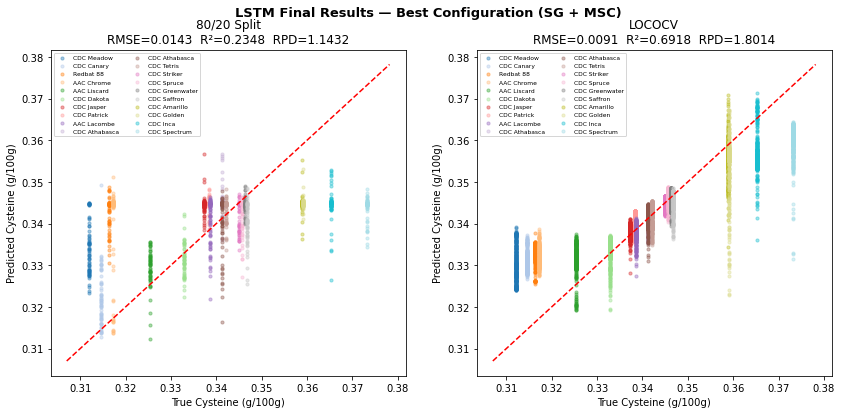

In [15]:
# Best LOCO = SG + MSC
X_best_lstm = msc(savitzky_golay_smooth(X))
X_tr, X_te, y_tr, y_te = train_test_split(
    X_best_lstm, y, test_size=0.2, random_state=42
)

torch.manual_seed(42)
model_lstm_final = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
model_lstm_final, _, _ = train_model(
    model=model_lstm_final,
    X_train=X_tr, y_train=y_tr,
    X_val=X_te,   y_val=y_te,
    epochs=100, batch_size=32, lr=1e-4
)

model_lstm_final.eval()
with torch.no_grad():
    y_pred_te_lstm = model_lstm_final(
        torch.FloatTensor(X_te).to(device)
    ).cpu().numpy()

# LOCOCV
all_true_lstm, all_pred_lstm = [], []
for fold_idx, held_out in enumerate(cultivar_names):
    X_tr_l, y_tr_l = [], []
    X_te_l, y_te_l = [], []

    for folder_name, meta in CULTIVARS.items():
        spectra = all_data.get(folder_name, [])
        for rs, intens in spectra:
            arr     = np.array([intens])
            arr_pre = msc(savitzky_golay_smooth(arr))[0]
            if folder_name == held_out:
                X_te_l.append(arr_pre)
                y_te_l.append(meta['cys'])
            else:
                X_tr_l.append(arr_pre)
                y_tr_l.append(meta['cys'])

    torch.manual_seed(42)
    model_lstm_loco = LSTMModel(input_size=1530, hidden_size=128, num_layers=2)
    model_lstm_loco, _, _ = train_model(
        model=model_lstm_loco,
        X_train=np.array(X_tr_l),
        y_train=np.array(y_tr_l),
        X_val=np.array(X_te_l),
        y_val=np.array(y_te_l),
        epochs=100, batch_size=32, lr=1e-4
    )

    model_lstm_loco.eval()
    with torch.no_grad():
        y_pred_l = model_lstm_loco(
            torch.FloatTensor(np.array(X_te_l)).to(device)
        ).cpu().numpy()

    fold_rmse = np.sqrt(mean_squared_error(y_te_l, y_pred_l))
    print(f"Fold {fold_idx+1}/20 {CULTIVARS[held_out]['label']:20s} RMSE: {fold_rmse:.4f}")
    all_true_lstm.extend(y_te_l)
    all_pred_lstm.extend(y_pred_l)

all_true_lstm = np.array(all_true_lstm)
all_pred_lstm = np.array(all_pred_lstm)

rmse_8020_lstm = np.sqrt(mean_squared_error(y_te, y_pred_te_lstm))
r2_8020_lstm   = r2_score(y_te, y_pred_te_lstm)
rpd_8020_lstm  = y_te.std() / rmse_8020_lstm
rmse_loco_lstm = np.sqrt(mean_squared_error(all_true_lstm, all_pred_lstm))
r2_loco_lstm   = r2_score(all_true_lstm, all_pred_lstm)
rpd_loco_lstm  = all_true_lstm.std() / rmse_loco_lstm

# ── Scatter Plot with different color per cultivar ──
colors = plt.cm.tab20(np.linspace(0, 1, 20))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
unique_cys = sorted(set(y_te))
for i, val in enumerate(unique_cys):
    mask  = y_te == val
    label = [meta['label'] for meta in CULTIVARS.values()
             if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax1.scatter(y_te[mask], y_pred_te_lstm[mask],
                alpha=0.4, s=10, color=colors[i], label=label)

min_val = min(y_te.min(), y_pred_te_lstm.min()) - 0.005
max_val = max(y_te.max(), y_pred_te_lstm.max()) + 0.005
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax1.set_xlabel("True Cysteine (g/100g)")
ax1.set_ylabel("Predicted Cysteine (g/100g)")
ax1.set_title(f"80/20 Split\nRMSE={rmse_8020_lstm:.4f}  R²={r2_8020_lstm:.4f}  RPD={rpd_8020_lstm:.4f}")
ax1.legend(fontsize=6, ncol=2, loc='upper left')

ax2 = axes[1]
unique_cys_loco = sorted(set(all_true_lstm))
for i, val in enumerate(unique_cys_loco):
    mask  = all_true_lstm == val
    label = [meta['label'] for meta in CULTIVARS.values()
             if abs(meta['cys'] - val) < 0.0001]
    label = label[0] if label else str(round(val, 4))
    ax2.scatter(all_true_lstm[mask], all_pred_lstm[mask],
                alpha=0.4, s=10, color=colors[i], label=label)

min_val = min(all_true_lstm.min(), all_pred_lstm.min()) - 0.005
max_val = max(all_true_lstm.max(), all_pred_lstm.max()) + 0.005
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
ax2.set_xlabel("True Cysteine (g/100g)")
ax2.set_ylabel("Predicted Cysteine (g/100g)")
ax2.set_title(f"LOCOCV\nRMSE={rmse_loco_lstm:.4f}  R²={r2_loco_lstm:.4f}  RPD={rpd_loco_lstm:.4f}")
ax2.legend(fontsize=6, ncol=2, loc='upper left')

plt.suptitle("LSTM Final Results — Best Configuration (SG + MSC)",
             fontsize=13, fontweight='bold')
plt.tigh

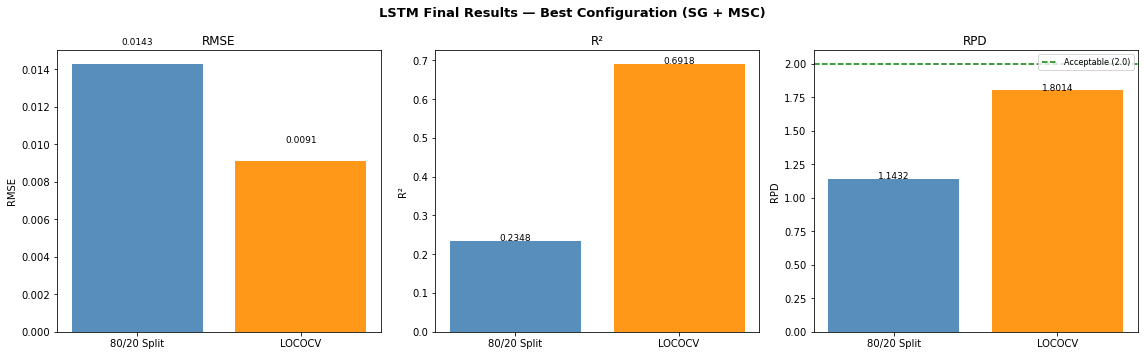


       LSTM FINAL RESULTS SUMMARY
Metric                   80/20 Split          LOCOCV
-------------------------------------------------------
RMSE                          0.0143          0.0091
R²                            0.2348          0.6918
RPD                           1.1432          1.8014
Preprocessing               SG + MSC        SG + MSC


In [16]:
# Use already computed results — no rerun needed
# Best LOCO config: SG + MSC
# Results from results_lstm_all

rmse_8020_lstm = 0.0143
r2_8020_lstm   = 0.2348
rpd_8020_lstm  = 1.1432
rmse_loco_lstm = 0.0091
r2_loco_lstm   = 0.6918
rpd_loco_lstm  = 1.8014

# Simple results summary plot without scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics   = ['RMSE', 'R²', 'RPD']
val_8020  = [rmse_8020_lstm, r2_8020_lstm, rpd_8020_lstm]
val_loco  = [rmse_loco_lstm, r2_loco_lstm, rpd_loco_lstm]

for i, (ax, metric, v1, v2) in enumerate(zip(axes, metrics, val_8020, val_loco)):
    bars = ax.bar(['80/20 Split', 'LOCOCV'], [v1, v2],
                  color=['steelblue', 'darkorange'], alpha=0.9)
    ax.set_title(f"{metric}")
    ax.set_ylabel(metric)
    for bar, val in zip(bars, [v1, v2]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', fontsize=9)
    if metric == 'R²':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if metric == 'RPD':
        ax.axhline(2.0, color='green', linewidth=1.5,
                   linestyle='--', label='Acceptable (2.0)')
        ax.legend(fontsize=8)

plt.suptitle("LSTM Final Results — Best Configuration (SG + MSC)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("LSTM_final_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*55)
print("       LSTM FINAL RESULTS SUMMARY")
print("="*55)
print(f"{'Metric':<20} {'80/20 Split':>15} {'LOCOCV':>15}")
print("-"*55)
print(f"{'RMSE':<20} {rmse_8020_lstm:>15.4f} {rmse_loco_lstm:>15.4f}")
print(f"{'R²':<20} {r2_8020_lstm:>15.4f} {r2_loco_lstm:>15.4f}")
print(f"{'RPD':<20} {rpd_8020_lstm:>15.4f} {rpd_loco_lstm:>15.4f}")
print(f"{'Preprocessing':<20} {'SG + MSC':>15} {'SG + MSC':>15}")
print("="*55)